## Build a model to find whether the person is defaulter or not when income & balance of the person is provided


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv('C:/Users/ADMIN/Desktop/FBS/Data Science/Data sets/Default.csv')

In [5]:
dataset.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [6]:
dataset['default'].unique()

array(['No', 'Yes'], dtype=object)

In [7]:
dataset['default'].nunique()

2

In [8]:
dataset['default'].count()

np.int64(10000)

In [9]:
dataset['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

<Axes: xlabel='income', ylabel='Count'>

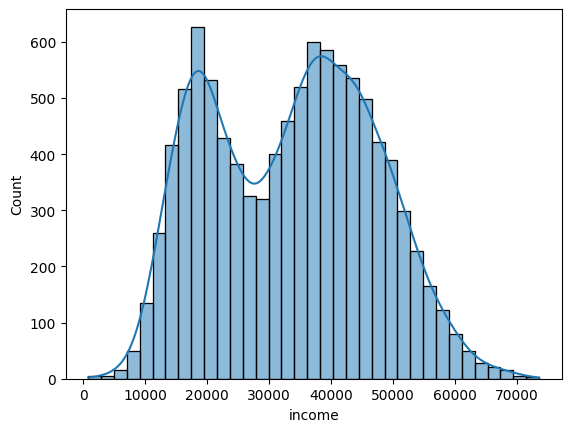

In [10]:
sns.histplot(dataset,x="income",kde = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x202d75cd580>,
 'caps': [<matplotlib.lines.Line2D at 0x202d9600290>,
 'boxes': [<matplotlib.lines.Line2D at 0x202d52bcce0>],
 'medians': [<matplotlib.lines.Line2D at 0x202d9600890>],
 'fliers': [<matplotlib.lines.Line2D at 0x202d9600bc0>],
 'means': []}

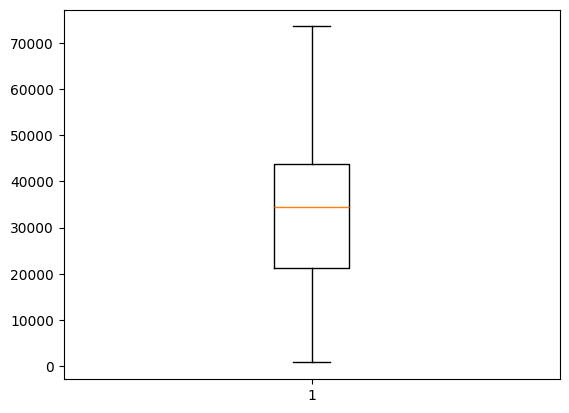

In [11]:
plt.boxplot(dataset['income'])

<Axes: xlabel='balance', ylabel='Count'>

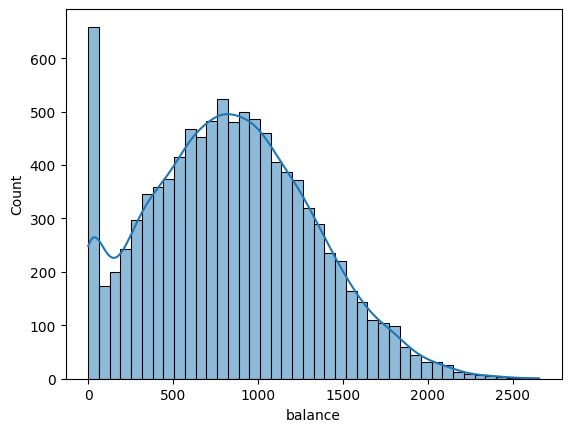

In [12]:
sns.histplot(dataset,x="balance",kde = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x202d96f7860>,
 'caps': [<matplotlib.lines.Line2D at 0x202d96f7e60>,
 'boxes': [<matplotlib.lines.Line2D at 0x202d96f75c0>],
 'medians': [<matplotlib.lines.Line2D at 0x202da874440>],
 'fliers': [<matplotlib.lines.Line2D at 0x202da874770>],
 'means': []}

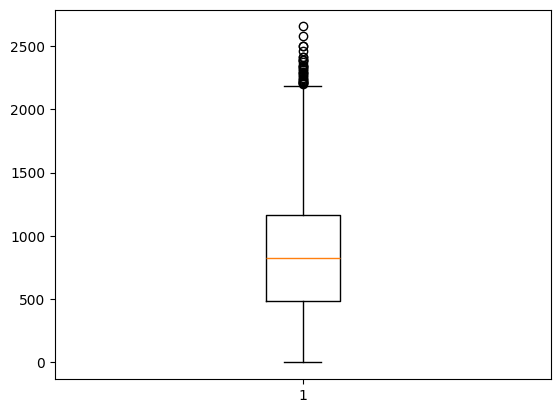

In [13]:
plt.boxplot(dataset['balance'])

In [6]:
q1 = dataset['balance'].quantile(0.25)

In [7]:
q3 = dataset['balance'].quantile(0.75)

In [8]:
IQR = q3-q1
IQR

684.5772817

In [9]:
upper = q3 + (IQR*1.5)
upper

2193.1743093

In [10]:
dataset[dataset['balance']>upper]['default'].value_counts()

default
Yes    26
No      5
Name: count, dtype: int64

In [19]:
# dataset[dataset['balance']>upper]['default'] #the data having outliers for baalnce

In [20]:
# out_ind = dataset[dataset['balance']>=2500].index
# dataset.drop(out_ind,inplace=True)

In [21]:
 dataset.drop(dataset[dataset['balance']>=2500].index,inplace=True)

### Encoding

In [22]:
dataset.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['student']= le.fit_transform(dataset['student'])

In [24]:
dataset.head()

,default,student,balance,income
0,No,0,729.526495,44361.62507
1,No,1,817.180407,12106.13470
2,No,0,1073.549164,31767.13895
3,No,0,529.250605,35704.49394
4,No,0,785.655883,38463.49588


## Divide X & y

In [25]:
X = dataset.drop('default',axis=1)
y= dataset['default']

## tranformation / scaling

In [26]:
dataset.describe()

,student,balance,income
count,9997.000000,9997.000000,9997.000000
mean,0.294188,834.851794,33520.779654
std,0.455700,482.842711,13336.614728
min,0.000000,0.000000,771.967729
25%,0.000000,481.591003,21341.653840
50%,0.000000,823.471373,34558.615780
75%,1.000000,1165.936504,43809.259950
max,1.000000,2499.016750,73554.233500


In [27]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_trans = ss.fit_transform(X)
x_trans

array([[-0.64560699, -0.21814675,  0.81290402],
       [ 1.54892994, -0.03660047, -1.60578352],
       [-0.64560699,  0.49438317, -0.13149727],
       ...,
       [-0.64560699,  0.02187198,  1.88328403],
       [-0.64560699,  1.52056553,  0.23607866],
       [ 1.54892994, -1.31297689, -1.24909213]], shape=(9997, 3))

In [28]:
X = pd.DataFrame(x_trans,columns=X.columns)
X

,student,balance,income
0,-0.645607,-0.218147,0.812904
1,1.548930,-0.036600,-1.605784
2,-0.645607,0.494383,-0.131497
3,-0.645607,-0.632952,0.163746
4,-0.645607,-0.101893,0.370631
...,...,...,...
9992,-0.645607,-0.255369,1.460084
9993,-0.645607,-0.159250,-1.039301
9994,-0.645607,0.021872,1.883284
9995,-0.645607,1.520566,0.236079


In [29]:
X.describe()

,student,balance,income
count,9.997000e+03,9.997000e+03,9.997000e+03
mean,-4.566607e-17,-6.681106e-17,-2.590705e-16
std,1.000050e+00,1.000050e+00,1.000050e+00
min,-6.456070e-01,-1.729121e+00,-2.455679e+00
25%,-6.456070e-01,-7.316636e-01,-9.132554e-01
50%,-6.456070e-01,-2.357080e-02,7.782245e-02
75%,1.548930e+00,6.857332e-01,7.714848e-01
max,1.548930e+00,3.446771e+00,3.001920e+00


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=40)

In [31]:
### Build model

In [32]:
from sklearn.neighbors import KNeighborsClassifier


### Building model with cross validation

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate

In [34]:
knn = KNeighborsClassifier(n_neighbors=7, metric="euclidean")
result = cross_validate(knn, X_train,y_train, cv=5, return_train_score=True)

In [35]:
result

{'fit_time': array([0.00842237, 0.01157784, 0.00051689, 0.00826311, 0.01564527]),
 'score_time': array([0.00857878, 0.01025438, 0.0260067 , 0.00167203, 0.        ]),
 'test_score': array([0.97428571, 0.97642857, 0.97212294, 0.97212294, 0.97355254]),
 'train_score': array([0.9755226 , 0.97570127, 0.97570561, 0.97642015, 0.97624151])}

In [36]:
result["train_score"]

array([0.9755226 , 0.97570127, 0.97570561, 0.97642015, 0.97624151])

In [37]:
print("Avg Training acc after cross validation",result["train_score"].mean())

Avg Training acc after cross validation 0.9759182287913516
